# Density Based Clustering

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

## Imports

In [62]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [63]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")
artists_df = pd.read_csv("../datasets/artists_cleaned.csv")

## Features Selection

In [64]:
selected_features = [
    # linguistic / lyrics
    # 'n_tokens',
    # 'swear_IT',
    # 'lexical_density',

    # audio features
    # 'bpm',
    'centroid',
    'loudness',
    'spectral_complexity',
    # 'flux',
    'rolloff',

    # popularity
    'popularity',
    # 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    'has_collaboration',
    'aggressiveness',
    # 'song_age',
    # 'duration_sec'
]

In [66]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [67]:
# Check for NaN values
print(X.isna().sum())

centroid               0
loudness               0
spectral_complexity    0
rolloff                0
popularity             0
has_collaboration      0
aggressiveness         0
dtype: int64


**log1p transformation**: applying log to numeric skewed features

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for clustering
numeric_features = X.columns.tolist()  # X is our selected features for clustering

# Step 0: Filter out binary and one-hot encoded features (only keep features with >2 unique values)
continuous_features = [col for col in numeric_features if X[col].nunique() > 2]

# Step 1: Compute skewness
skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n", skewness)

# Step 2: Plot distribution of highly skewed features (optional)
high_skew = skewness[skewness > 2].index  # threshold for positive skew
# for col in high_skew:
#     plt.figure()
#     sns.histplot(X[col], kde=True)
#     plt.title(f'Distribution of {col} (skew={skewness[col]:.2f})')
#     plt.show()

# Step 3: Apply log1p transformation to highly skewed continuous features
for col in high_skew:
    # Only apply if all values are >= 0 (log1p cannot handle negative values)
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])
    else:
        print(f"Skipping {col} because it has negative values.")

# Step 4: Verify the new skewness
new_skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness after log1p transformation:\n", new_skewness)

Skewness of continuous features:
 popularity             0.260412
centroid               0.181541
spectral_complexity    0.099082
aggressiveness        -0.053941
rolloff               -0.060360
loudness              -0.153119
dtype: float64
Skewness after log1p transformation:
 popularity             0.260412
centroid               0.181541
spectral_complexity    0.099082
aggressiveness        -0.053941
rolloff               -0.060360
loudness              -0.153119
dtype: float64


**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [69]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [70]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

In [71]:
X_scaled = X_minmax

## DBScan

### Study of Clustering Parameters

In DBSCAN, we have to choose two parameters:

* **eps:** The maximum distance between two samples for one to be considered as in the neighborhood of the other.

* **min_samples:** The number of samples (or total weight) in a neighborhood for a point to be considered as a core point.

We can find the best parameters for the DBSCAN by using the silhouette score, which is a measure of how similar an object is to its own cluster compared to other clusters, and it ranges from -1 to 1.

We thought of doing a grid search for the parameters by computing the silhouette score for different comibnations of parameters and then choose the combination that gave the best score.

So the first thing to do now is to find the search ranges for each parameter that we'll use for the grid search.

To find a good range of values for eps, we first plot a graph of the distance to the nearest neighbor of each point (sorted by distance). Then we look for a spot in the graph where the distances suddenly increase. This point is called the knee or elbow, and it gives us a good estimate for eps. This is known as the knee method.

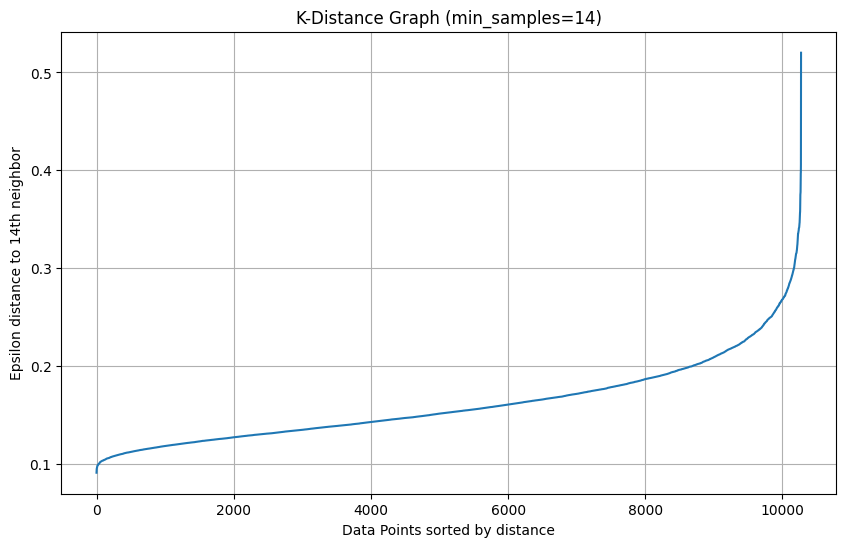

In [72]:
# 1. Select min_samples
min_samples = 2 * len(selected_features)  # Default value: 2*D

# 2. Calculate distance to the kth nearest neighbor
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 3. Sort distances (we only care about the distance to the min_samples-th neighbor)
distances = np.sort(distances[:, min_samples-1], axis=0)

# 4. Plot the k-distance Graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title(f'K-Distance Graph (min_samples={min_samples})')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'Epsilon distance to {min_samples}th neighbor')
plt.grid(True)
plt.show()

These are util functions that automatically generate value ranges for both parameters. This are completely optional, we could've done this step manually by hard-coding the range values in the source code, but we wanted to make it automatically generated to be able to test many values quickly to determin the best ranges.

In [ ]:
def generate_min_samples_range(D, num_values):
    """
    Generates a range of min_samples values centered around 2*D.
    D: Number of dimensions (features).
    num_values: The desired total number of values in the output list.
    """
    # Heuristic center point
    center = 2 * D
    
    # Calculate the span (e.g. 5 steps above and below the center)
    span = max(D // 2, 5) 
    
    start = max(5, center - span) # min_samples should be >= 5
    end = center + span + 1
    
    # Generate num_values points evenly spaced within [start, end]
    min_samples_range = np.linspace(start, end, num_values, dtype=int)
    
    # Ensure all generated values are unique and greater than 5
    return np.unique(min_samples_range[min_samples_range >= 5]).tolist()

Now we will generate the value ranges for both parameters, for min samples, we used the 2*D as a heuristic, so the range values are centered around it, and for the eps, we used the knee method to read the knee value and use it as a heuristic to determin the range of possible eps values.

In [ ]:
min_samples_range = generate_min_samples_range(len(selected_features), 6)
eps_range = np.round(np.linspace(0.17, 0.28, 10), 2).tolist()
print("Parameters for the grid search:\nmin_samples: {0}\neps: {1}".format(min_samples_range, eps_range))

Parameters for the grid search:
min_samples: [9, 11, 13, 15, 17, 20]
eps: [0.17, 0.18, 0.19, 0.21, 0.22, 0.23, 0.24, 0.26, 0.27, 0.28]


**Grid Search:**

In [77]:
results = []

print(f"Starting Grid Search with {len(eps_range) * len(min_samples_range)} combinations...")

for eps in eps_range:
    for min_samples in min_samples_range:
        
        # Run DBSCAN
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        # Count clusters (ignoring noise which is -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels)
        
        # We only care if we found at least 2 clusters and not everything is noise
        if n_clusters > 1 and noise_ratio < 0.9:
            # Calculate Silhouette Score
            sil_score = silhouette_score(X_scaled, labels)
            
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'noise_ratio': noise_ratio,
                'silhouette': sil_score
            })
            
# Create a DataFrame of results
results_df = pd.DataFrame(results)

Starting Grid Search with 60 combinations...


In [78]:
grid_search_results = results_df.copy()

In [79]:
# Sort by best Silhouette Score
print("Top 5 Parameter Combinations:")
print(grid_search_results.sort_values(by='silhouette', ascending=False).head(5))

Top 5 Parameter Combinations:
     eps  min_samples  n_clusters  noise_ratio  silhouette
44  0.26           13           2     0.002044    0.483057
36  0.24            9           2     0.003991    0.480524
45  0.26           15           2     0.002726    0.480385
46  0.26           17           2     0.003407    0.479872
47  0.26           20           2     0.004186    0.478770


Heatmap Visualization of the grid search results

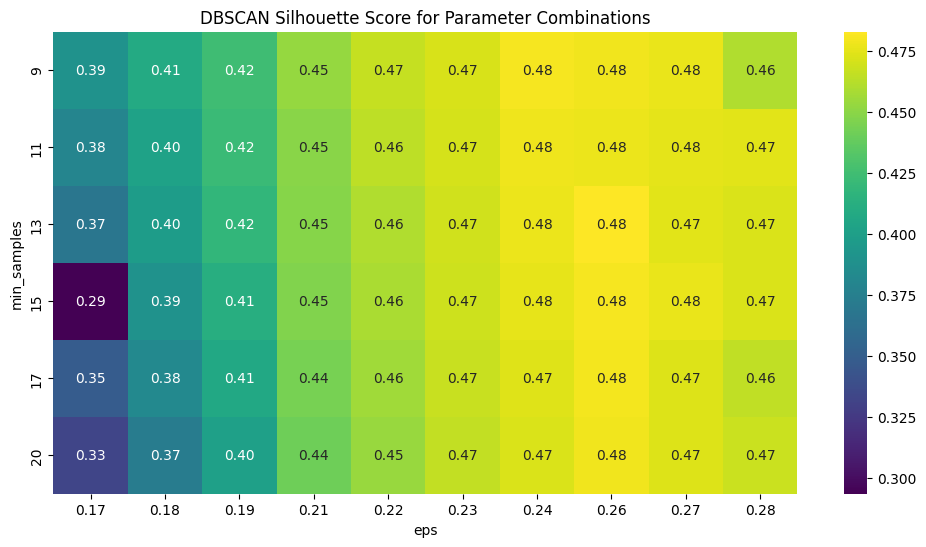

In [86]:
# Pivot table for the heatmap
results_tmp = grid_search_results.copy()
pivot_table = results_tmp.pivot(index='min_samples', columns='eps', values='silhouette')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".2f")
plt.title('DBSCAN Silhouette Score for Parameter Combinations')
plt.show()

In [87]:
# # 2 heatmaps, one for cluster numbers, and one for silhouette score

# results_tmp = grid_search_results.copy()

# # Pivot tables for heatmaps
# df_clusters_grid = results_tmp.pivot(index='eps', columns='min_samples', values='n_clusters')
# df_sil_grid      = results_tmp.pivot(index='eps', columns='min_samples', values='silhouette')

# # Convert cluster grid to integers (silhouette stays float)
# df_clusters_grid_int = df_clusters_grid.fillna(0).astype(int)

# fig, axs = plt.subplots(1, 2, figsize=(22, 8))

# # --- Heatmap 1: Number of Clusters ---
# sns.heatmap(
#     df_clusters_grid_int,
#     annot=True,
#     fmt="d",
#     cmap="coolwarm",
#     cbar=False,
#     ax=axs[0]
# )
# axs[0].set_title("Number of Clusters")
# axs[0].set_xlabel("min_samples")
# axs[0].set_ylabel("epsilon")

# # --- Heatmap 2: Silhouette Score ---
# sns.heatmap(
#     df_sil_grid,
#     annot=True,
#     fmt=".3f",
#     cmap="coolwarm",
#     cbar=False,
#     ax=axs[1]
# )
# axs[1].set_title("Silhouette Score")
# axs[1].set_xlabel("min_samples")
# axs[1].set_ylabel("epsilon")

# plt.tight_layout()
# plt.show()


Best possible combination

In [82]:
# Filter results to only those with at least 2 clusters
valid_results = grid_search_results[grid_search_results['n_clusters'] >= 2]

if valid_results.empty:
    print("No valid parameter combinations found with n_clusters >= 2.")
else:
    # Pick combination with highest silhouette score
    best_result = valid_results.sort_values(by='silhouette', ascending=False).iloc[0]

    print("\nBest Parameters Found (n_clusters > 2):")
    print(f"eps = {best_result['eps']}")
    print(f"min_samples = {best_result['min_samples']}")
    print(f"n_clusters = {best_result['n_clusters']}")
    print(f"noise_ratio = {best_result['noise_ratio']:.2%}")
    print(f"silhouette_score = {best_result['silhouette']:.4f}")



Best Parameters Found (n_clusters > 2):
eps = 0.26
min_samples = 13.0
n_clusters = 2.0
noise_ratio = 0.20%
silhouette_score = 0.4831


In [ ]:
# Extract best parameters
best_eps = float(best_result['eps'])
best_min_samples = int(best_result['min_samples'])

Validate the best parameters using K-distance graph and knee method

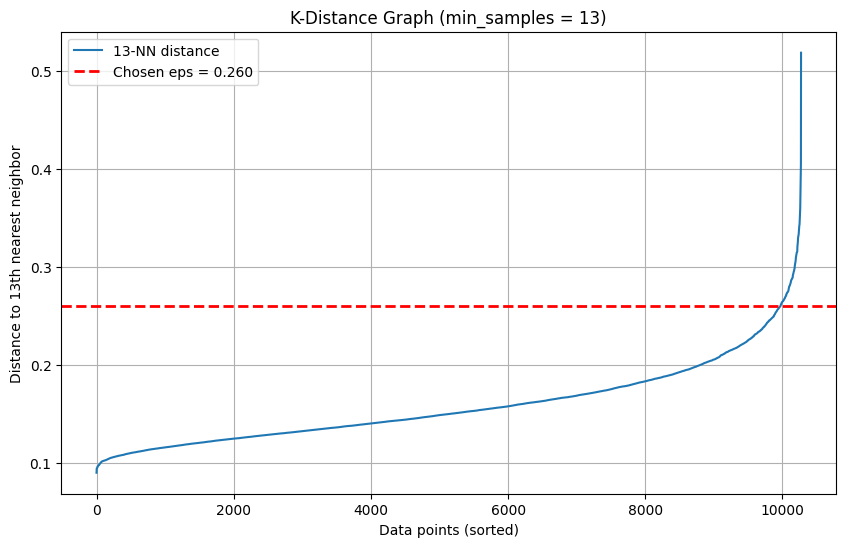

In [85]:
# 1. Use best_min_samples
k = best_min_samples

# 2. Compute k-nearest neighbor distances
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

# 3. Sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, k - 1])

# 4. Plot k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances, label=f'{k}-NN distance')
plt.axhline(
    y=best_eps,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Chosen eps = {best_eps:.3f}'
)

plt.title(f'K-Distance Graph (min_samples = {k})')
plt.xlabel('Data points (sorted)')
plt.ylabel(f'Distance to {k}th nearest neighbor')
plt.legend()
plt.grid(True)
plt.show()


**DBSCAN Algorithm:** Now we can run the algorithm using the best found parameters

In [ ]:
# RUN DBSCAN
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels = dbscan.fit_predict(X_scaled)

# Add labels to dataframe
X['dbscan_cluster'] = labels

# Count clusters
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

# Compute silhouette score
silhouette = silhouette_score(X_scaled, labels)

# Print results
print(f'DBSCAN (eps={best_eps}, min_samples={best_min_samples})')
print(f'Number of labels: {len(set(labels))}')
print(f'Number of clusters: {n_clusters_}')
print(f'Number of noise points: {n_noise_}')
print(f'Noise ratio: {n_noise_ / len(labels):.2%}')
print(f'Silhouette score: {silhouette:.4f}')

# Print count of each label
print("\nCounts per label:")
print(pd.Series(labels).value_counts().sort_index())


DBSCAN (eps=0.26, min_samples=13)
Number of labels: 3
Number of clusters: 2
Number of noise points: 21
Noise ratio: 0.20%
Silhouette score: 0.4831

Counts per label:
-1      21
 0    3347
 1    6904
Name: count, dtype: int64
